# Loading and Formatting Data

In [1]:
import os
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Rename Title

In [2]:
class KidneyStoneDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(self.labels_dir, txt_name)
        
        label = 0.0 
        
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == '0':
                        label = 1.0 
                        break 
                        
        label = torch.tensor([label], dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# Use a base directory to clean up path formatting
base_dir = 'C:/Users/paulw/OneDrive/Desktop/BME 450/archive'

training_data = KidneyStoneDataset(
    images_dir=f'{base_dir}/train/images', 
    labels_dir=f'{base_dir}/train/labels', 
    transform=data_transforms
)

valid_data = KidneyStoneDataset(
    images_dir=f'{base_dir}/valid/images', 
    labels_dir=f'{base_dir}/valid/labels', 
    transform=data_transforms
)

train_dataloader = DataLoader(training_data, batch_size=16, shuffle=True)
valid_dataloader = DataLoader(valid_data, batch_size=16, shuffle=False)

print(f"Total training scans: {len(training_data)}")
print(f"Total validation scans: {len(valid_data)}")

Total training scans: 1054
Total validation scans: 123


# Rename Title

In [3]:
class SimpleKidneyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 1) 

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x) 
        return x

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    train_loss = 0
    num_batches = len(dataloader)
    model.train()
    
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        if batch % 10 == 0: 
            loss_val, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")
            
    return train_loss / num_batches

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    model.eval()
    
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            predicted_classes = (torch.sigmoid(pred) > 0.5).float()
            correct += (predicted_classes == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss

# Rename Title

Epoch 1
-------------------------------
loss: 0.666831  [   16/ 1054]
loss: 0.000000  [  176/ 1054]
loss: 0.000000  [  336/ 1054]
loss: 0.000000  [  496/ 1054]
loss: 0.000000  [  656/ 1054]
loss: 0.000000  [  816/ 1054]
loss: 0.000000  [  976/ 1054]
Test Error: 
 Accuracy: 100.0%, Avg loss: 0.000000 

Epoch 2
-------------------------------
loss: 0.000000  [   16/ 1054]
loss: 0.000000  [  176/ 1054]
loss: 0.000000  [  336/ 1054]
loss: 0.000000  [  496/ 1054]
loss: 0.000000  [  656/ 1054]
loss: 0.000000  [  816/ 1054]
loss: 0.000000  [  976/ 1054]
Test Error: 
 Accuracy: 100.0%, Avg loss: 0.000020 

Epoch 3
-------------------------------
loss: 0.000084  [   16/ 1054]
loss: 0.000000  [  176/ 1054]
loss: 0.000000  [  336/ 1054]
loss: 0.000000  [  496/ 1054]
loss: 0.000000  [  656/ 1054]
loss: 0.000000  [  816/ 1054]
loss: 0.000000  [  976/ 1054]
Test Error: 
 Accuracy: 100.0%, Avg loss: 0.000000 

Epoch 4
-------------------------------
loss: 0.000000  [   16/ 1054]
loss: 0.000000  [  17

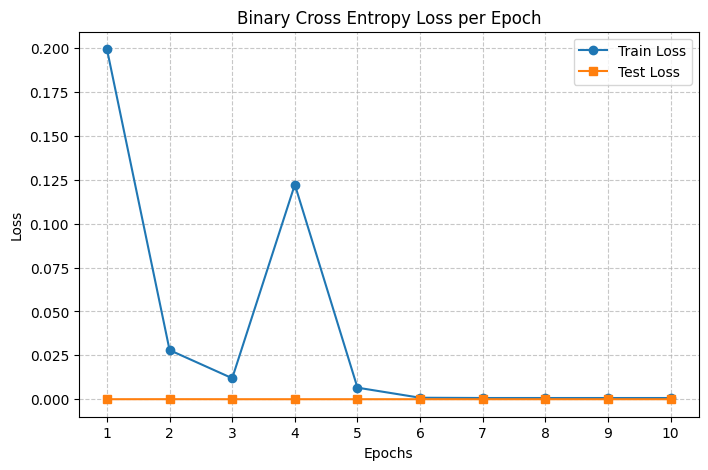

In [4]:
# Initialize Model, Loss, and Optimizer
model = SimpleKidneyCNN()
loss_fn = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Execution Loop
epochs = 10
train_losses = []
test_losses = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    avg_train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    avg_test_loss = test_loop(valid_dataloader, model, loss_fn)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    
print("Training Complete!")

# Plot Training Progress
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', marker='s')
plt.title('Binary Cross Entropy Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(1, epochs + 1)) 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Neural network probability (sigmoid): 100.00%
True class: Stone Present | Predicted: Stone Present


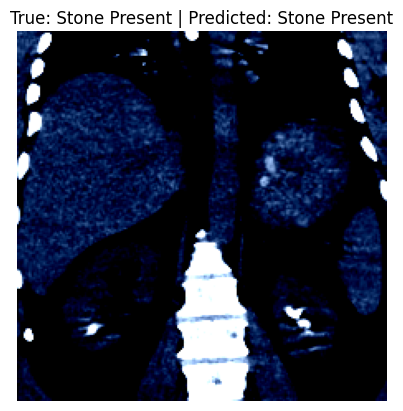

Result: Correct!

Neural network probability (sigmoid): 100.00%
True class: Stone Present | Predicted: Stone Present


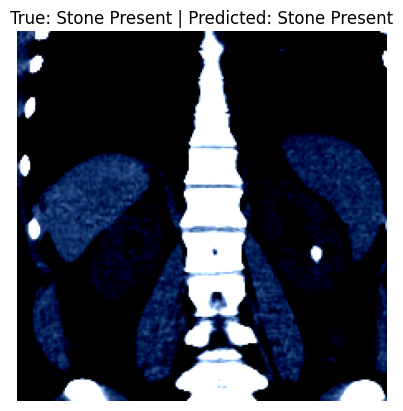

Result: Correct!

Neural network probability (sigmoid): 100.00%
True class: Stone Present | Predicted: Stone Present


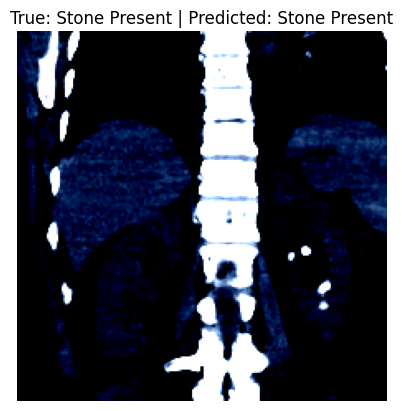

Result: Correct!



In [5]:
sample_index = [2, 5, 8]

for i in sample_index:
    image_tensor, true_label_tensor = valid_data[i]
    true_val = true_label_tensor.item()
    true_category = "Stone Present" if true_val == 1.0 else "Healthy"

    model.eval()
    with torch.no_grad():
        input_batch = image_tensor.unsqueeze(0)
        output = model(input_batch)
        
    probability = torch.sigmoid(output[0]).item()
    predicted_val = 1.0 if probability > 0.5 else 0.0
    predicted_category = "Stone Present" if predicted_val == 1.0 else "Healthy"
    
    print(f'Neural network probability (sigmoid): {probability * 100:.2f}%')
    print(f'True class: {true_category} | Predicted: {predicted_category}')
    
    image_to_plot = image_tensor.permute(1, 2, 0)
    image_to_plot = torch.clamp(image_to_plot, 0, 1)
    
    plt.imshow(image_to_plot.numpy())
    plt.title(f"True: {true_category} | Predicted: {predicted_category}")
    plt.axis('off') 
    plt.show()
    
    print("Result: Correct!\n" if true_category == predicted_category else "Result: Incorrect!\n")

# Rename Title

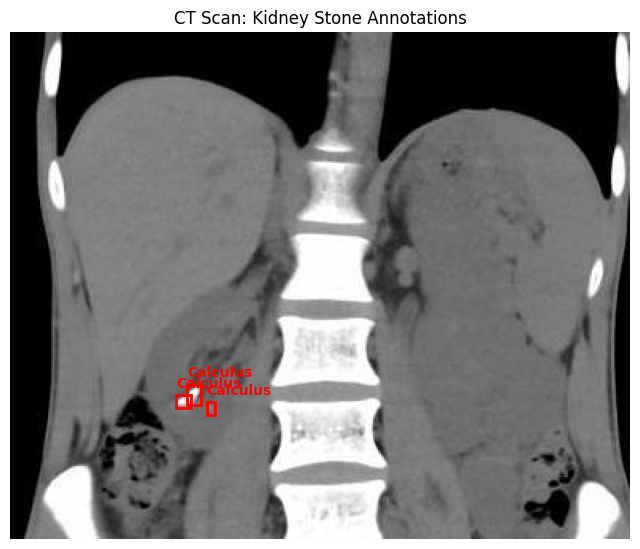

In [6]:
def visualize_yolo_labels(image_path, label_path):
    img = Image.open(image_path).convert('RGB')
    img_width, img_height = img.size
    
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as file:
            for line in file:
                parts = line.strip().split()
                if len(parts) >= 5 and parts[0] == '0':
                    x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                    w = w_norm * img_width
                    h = h_norm * img_height
                    x_min = (x_c * img_width) - (w / 2)
                    y_min = (y_c * img_height) - (h / 2)
                    
                    rect = patches.Rectangle((x_min, y_min), w, h, linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
                    plt.text(x_min, y_min - 5, 'Calculus', color='red', fontsize=10, weight='bold')

    plt.axis('off')
    plt.title("CT Scan: Kidney Stone Annotations")
    plt.show()

# Example Usage (Fixed Paths)
filename = '1-3-46-670589-33-1-63703718086120120200001-5487554579919763006_png_jpg.rf.9fd67251e99a47dbe83a5db6efe6c016'
sample_image = f'{base_dir}/test/images/{filename}.jpg'
sample_label = f'{base_dir}/test/labels/{filename}.txt'

visualize_yolo_labels(sample_image, sample_label)